         DIABETES PREDICTION MODEL

📦 Dataset Shape: (768, 9)

🎯 Class Distribution:
   Non-Diabetic (0): 214
   Diabetic     (1): 554

🔍 Missing Values: 0

📊 First 5 Rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            4      136             50             16       20  27.6   
1            6      116             33             33       48  44.7   
2            3      141             77             36        0  37.0   
3            4      169             43              4       40  28.1   
4            0      113             36             22       76  36.4   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.497   71        1  
1                     0.253   25        1  
2                     0.694   49        1  
3                     0.515   57        1  
4                     0.601   40        1  

📈 Statistics:
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         7

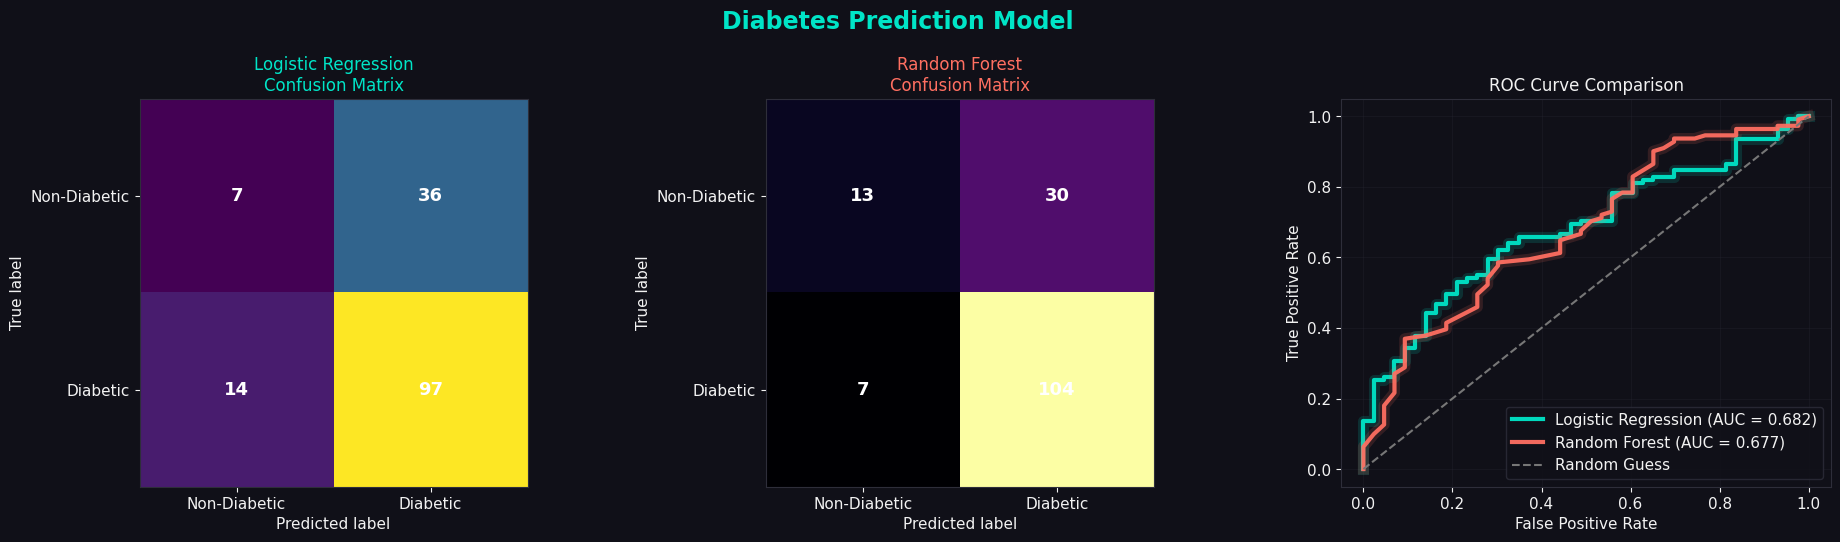


📊 Plot saved as task5_diabetes_plots.png


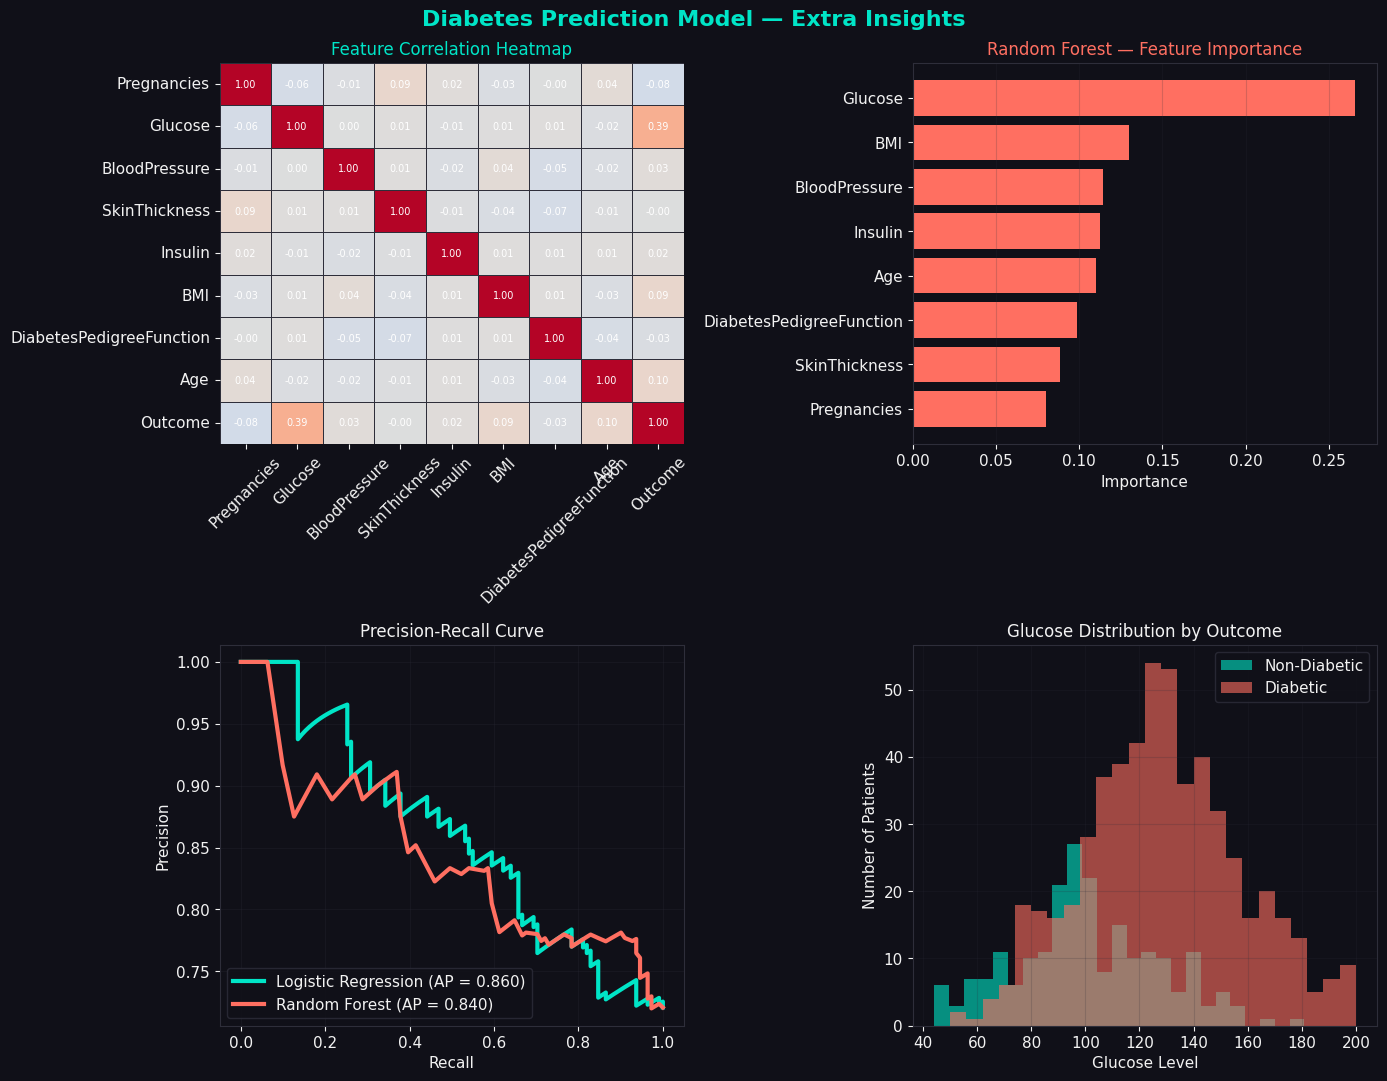

📊 Extra plot saved as task5_diabetes_extra_plots.png

🎉 Task 5 Complete!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, ConfusionMatrixDisplay, accuracy_score,
                             precision_recall_curve, average_precision_score)
import seaborn as sns

# ── STYLE SETUP (new look) ───────────────────────────────────
plt.style.use("dark_background")
ACCENT_1   = "#00E5C7"   # teal
ACCENT_2   = "#FF6F61"   # coral
GRID_COLOR = "#2E2E3A"
BG_COLOR   = "#101018"
TEXT_COLOR = "#F2F2F2"

plt.rcParams.update({
    "figure.facecolor": BG_COLOR,
    "axes.facecolor": BG_COLOR,
    "axes.edgecolor": GRID_COLOR,
    "axes.labelcolor": TEXT_COLOR,
    "xtick.color": TEXT_COLOR,
    "ytick.color": TEXT_COLOR,
    "text.color": TEXT_COLOR,
    "grid.color": GRID_COLOR,
    "font.family": "DejaVu Sans",
    "font.size": 11,
})

# ── 1. CREATE DATASET ────────────────────────────────────────
print("=" * 55)
print("         DIABETES PREDICTION MODEL")
print("=" * 55)

# Pima Indians Diabetes Dataset (recreated as inline data)
np.random.seed(42)
n = 768

glucose     = np.random.normal(121, 32, n).clip(44, 200).astype(int)
bmi         = np.random.normal(32, 7, n).clip(18, 67).round(1)
age         = np.random.randint(21, 81, n)
pregnancies = np.random.randint(0, 17, n)
bp          = np.random.normal(69, 19, n).clip(0, 122).astype(int)
insulin     = np.random.normal(80, 115, n).clip(0, 846).astype(int)
skin        = np.random.normal(20, 16, n).clip(0, 99).astype(int)
dpf         = np.random.normal(0.47, 0.33, n).clip(0.08, 2.42).round(3)

# Target: diabetic (1) or not (0) — higher glucose/bmi = higher chance
prob = 1 / (1 + np.exp(-(0.03*glucose + 0.05*bmi + 0.02*age - 5)))
outcome = (np.random.rand(n) < prob).astype(int)

df = pd.DataFrame({
    "Pregnancies": pregnancies, "Glucose": glucose,
    "BloodPressure": bp, "SkinThickness": skin,
    "Insulin": insulin, "BMI": bmi,
    "DiabetesPedigreeFunction": dpf, "Age": age,
    "Outcome": outcome
})

print("\n📦 Dataset Shape:", df.shape)
print("\n🎯 Class Distribution:")
print(f"   Non-Diabetic (0): {(df['Outcome']==0).sum()}")
print(f"   Diabetic     (1): {(df['Outcome']==1).sum()}")
print("\n🔍 Missing Values:", df.isnull().sum().sum())
print("\n📊 First 5 Rows:")
print(df.head())
print("\n📈 Statistics:")
print(df.describe().round(2))

# ── 2. HANDLE ZEROS (treat as missing in medical features) ───
cols_with_zeros = ["Glucose", "BloodPressure", "SkinThickness", "BMI", "Insulin"]
for col in cols_with_zeros:
    df[col] = df[col].replace(0, df[col].median())
print("\n✅ Zero values replaced with median (data cleaning done)")

# ── 3. FEATURES & TARGET ─────────────────────────────────────
features = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
            "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]
X = df[features]
y = df["Outcome"]

# ── 4. TRAIN / TEST SPLIT ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\n✂️  Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

# ── 5. SCALE FEATURES ────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── 6. TRAIN MODELS ──────────────────────────────────────────
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

print("\n✅ Models trained successfully!")

# ── 7. EVALUATE ──────────────────────────────────────────────
for name, model in [("Logistic Regression", lr_model), ("Random Forest", rf_model)]:
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{'='*45}")
    print(f"📊 {name} — Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred,
          target_names=["Non-Diabetic", "Diabetic"]))

# ── 8. VISUALIZATIONS (new color scheme) ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle("Diabetes Prediction Model", fontsize=17, fontweight="bold", color=ACCENT_1)

# Plot 1: Confusion Matrix — Logistic Regression (teal colormap, custom digit color)
lr_pred = lr_model.predict(X_test_scaled)
cm_lr = confusion_matrix(y_test, lr_pred)
disp = ConfusionMatrixDisplay(cm_lr, display_labels=["Non-Diabetic", "Diabetic"])
disp.plot(ax=axes[0], colorbar=False, cmap="viridis")
for text in disp.text_.ravel():
    text.set_color("#FFFFFF")
    text.set_fontweight("bold")
    text.set_fontsize(13)
axes[0].set_title("Logistic Regression\nConfusion Matrix", color=ACCENT_1, fontsize=12)

# Plot 2: Confusion Matrix — Random Forest (coral colormap, custom digit color)
rf_pred = rf_model.predict(X_test_scaled)
cm_rf = confusion_matrix(y_test, rf_pred)
disp2 = ConfusionMatrixDisplay(cm_rf, display_labels=["Non-Diabetic", "Diabetic"])
disp2.plot(ax=axes[1], colorbar=False, cmap="inferno")
for text in disp2.text_.ravel():
    text.set_color("#FFFFFF")
    text.set_fontweight("bold")
    text.set_fontsize(13)
axes[1].set_title("Random Forest\nConfusion Matrix", color=ACCENT_2, fontsize=12)

# Plot 3: ROC Curves (teal vs coral, glow-style lines)
for name, model, color in [("Logistic Regression", lr_model, ACCENT_1),
                             ("Random Forest", rf_model, ACCENT_2)]:
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[2].plot(fpr, tpr, color=color, lw=3, alpha=0.95,
                 label=f"{name} (AUC = {roc_auc:.3f})")
    axes[2].plot(fpr, tpr, color=color, lw=8, alpha=0.15)  # glow effect

axes[2].plot([0, 1], [0, 1], color="#777777", linestyle="--", lw=1.5, label="Random Guess")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].set_title("ROC Curve Comparison", color=TEXT_COLOR, fontsize=12)
axes[2].legend(loc="lower right", facecolor=BG_COLOR, edgecolor=GRID_COLOR, labelcolor=TEXT_COLOR)
axes[2].grid(True, alpha=0.25)

for ax in axes:
    for spine in ax.spines.values():
        spine.set_color(GRID_COLOR)

plt.tight_layout()
plt.savefig("task5_diabetes_plots.png", dpi=150, bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print("\n📊 Plot saved as task5_diabetes_plots.png")

# ── 9. EXTRA VISUALIZATIONS ───────────────────────────────────
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 11))
fig2.patch.set_facecolor(BG_COLOR)
fig2.suptitle("Diabetes Prediction Model — Extra Insights", fontsize=16, fontweight="bold", color=ACCENT_1)

# Plot A: Correlation Heatmap
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            ax=axes2[0, 0], cbar=False, linewidths=0.5, linecolor=GRID_COLOR,
            annot_kws={"size": 7, "color": "white"})
axes2[0, 0].set_title("Feature Correlation Heatmap", color=ACCENT_1, fontsize=12)
axes2[0, 0].tick_params(axis='x', rotation=45)

# Plot B: Feature Importance (Random Forest)
importances = pd.Series(rf_model.feature_importances_, index=features)
top_feat = importances.sort_values(ascending=False)
bars = axes2[0, 1].barh(top_feat.index[::-1], top_feat.values[::-1], color=ACCENT_2)
axes2[0, 1].set_title("Random Forest — Feature Importance", color=ACCENT_2, fontsize=12)
axes2[0, 1].set_xlabel("Importance")
axes2[0, 1].grid(True, alpha=0.2, axis="x")

# Plot C: Precision-Recall Curve
for name, model, color in [("Logistic Regression", lr_model, ACCENT_1),
                             ("Random Forest", rf_model, ACCENT_2)]:
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    axes2[1, 0].plot(rec, prec, color=color, lw=3, label=f"{name} (AP = {ap:.3f})")
axes2[1, 0].set_xlabel("Recall")
axes2[1, 0].set_ylabel("Precision")
axes2[1, 0].set_title("Precision-Recall Curve", color=TEXT_COLOR, fontsize=12)
axes2[1, 0].legend(loc="lower left", facecolor=BG_COLOR, edgecolor=GRID_COLOR, labelcolor=TEXT_COLOR)
axes2[1, 0].grid(True, alpha=0.25)

# Plot D: Glucose Distribution by Outcome
axes2[1, 1].hist(df.loc[df.Outcome == 0, "Glucose"], bins=25, alpha=0.6,
                  color=ACCENT_1, label="Non-Diabetic")
axes2[1, 1].hist(df.loc[df.Outcome == 1, "Glucose"], bins=25, alpha=0.6,
                  color=ACCENT_2, label="Diabetic")
axes2[1, 1].set_xlabel("Glucose Level")
axes2[1, 1].set_ylabel("Number of Patients")
axes2[1, 1].set_title("Glucose Distribution by Outcome", color=TEXT_COLOR, fontsize=12)
axes2[1, 1].legend(facecolor=BG_COLOR, edgecolor=GRID_COLOR, labelcolor=TEXT_COLOR)
axes2[1, 1].grid(True, alpha=0.2)

for ax in axes2.ravel():
    for spine in ax.spines.values():
        spine.set_color(GRID_COLOR)

plt.tight_layout()
plt.savefig("task5_diabetes_extra_plots.png", dpi=150, bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print("📊 Extra plot saved as task5_diabetes_extra_plots.png")

print("\n🎉 Task 5 Complete!")